In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("PyTorch:", torch.__version__)

Mounted at /content/drive
Device: cuda
PyTorch: 2.10.0+cu128


In [3]:
file_path = '/content/drive/MyDrive/quark-gluon_data-set_n139306 (1).hdf5'
with h5py.File(file_path, 'r') as f:
    print("Shape:", f['X_jets'].shape)

Shape: (139306, 125, 125, 3)


In [5]:
MAX_NODES = 128
K_NEIGHBORS = 16
NODE_FEATURES = 7  # x, y, ecal, hcal, tracks, total_energy, log_energy
N_GLOBAL = 7       # n_particles, jet_width, ecal_frac, hcal_frac, tracks_frac, max_e_frac, ptd

def process_jet_image(image, max_nodes=MAX_NODES):
    """Convert 125x125x3 jet image to point cloud + global physics features.
    Returns: (point_cloud [max_nodes, 7], global_features [7])
    """
    mask = np.any(image > 0, axis=-1)
    coords = np.argwhere(mask)

    if len(coords) == 0:
        return np.zeros((max_nodes, NODE_FEATURES), dtype=np.float32), np.zeros(N_GLOBAL, dtype=np.float32)

    x = coords[:, 0] / 124.0
    y = coords[:, 1] / 124.0
    ecal   = image[coords[:, 0], coords[:, 1], 0]
    hcal   = image[coords[:, 0], coords[:, 1], 1]
    tracks = image[coords[:, 0], coords[:, 1], 2]
    total_e = ecal + hcal + tracks
    jet_total = total_e.sum()
    n_pix = len(coords)

    # Global features (computed from ALL active pixels, before truncation)
    if jet_total > 0:
        x_mean = np.sum(x * total_e) / jet_total
        y_mean = np.sum(y * total_e) / jet_total
        jet_width = np.sqrt(np.sum(total_e * ((x - x_mean)**2 + (y - y_mean)**2)) / jet_total)
        ecal_frac = ecal.sum() / jet_total
        hcal_frac = hcal.sum() / jet_total
        tracks_frac = tracks.sum() / jet_total
        max_e_frac = total_e.max() / jet_total
        ptd = np.sqrt(np.sum(total_e**2)) / jet_total
    else:
        jet_width = ecal_frac = hcal_frac = tracks_frac = max_e_frac = ptd = 0.0

    global_feats = np.array([
        n_pix, jet_width, ecal_frac, hcal_frac, tracks_frac, max_e_frac, ptd
    ], dtype=np.float32)

    # Point cloud (top MAX_NODES by energy)
    log_e = np.log1p(total_e)
    pc = np.stack([x, y, ecal, hcal, tracks, total_e, log_e], axis=1).astype(np.float32)

    if len(pc) > max_nodes:
        top_idx = np.argsort(total_e)[-max_nodes:]
        pc = pc[top_idx]
    elif len(pc) < max_nodes:
        pad = max_nodes - len(pc)
        pc = np.vstack([pc, np.zeros((pad, NODE_FEATURES), dtype=np.float32)])

    return pc, global_feats


def build_knn_spatial(x, k=K_NEIGHBORS):
    """Built KNN graph from spatial coordinates (x, y) only."""
    coords = x[:, :, :2]
    dist = torch.cdist(coords, coords)

    node_mask = (x.abs().sum(dim=-1) > 0).float()
    invalid = (1 - node_mask).unsqueeze(1) * 1e9
    dist = dist + invalid

    B, N, _ = dist.shape
    self_mask = torch.eye(N, device=x.device).unsqueeze(0) * 1e9
    dist = dist + self_mask

    _, knn_idx = dist.topk(k, dim=-1, largest=False)
    return knn_idx


def augment_pointcloud(x):
    """Training-time augmentation: random rotation + flip of spatial coords.
    x: (B, N, C) on device. Returns augmented copy.
    """
    B, N, C = x.shape
    node_mask = (x.abs().sum(dim=-1) > 0).float().unsqueeze(-1)  # (B, N, 1)
    x_aug = x.clone()

    # Random rotation per sample around center (0.5, 0.5)
    angle = torch.rand(B, device=x.device) * 2 * 3.14159265
    cos_a = torch.cos(angle).view(B, 1)
    sin_a = torch.sin(angle).view(B, 1)
    cx = x[:, :, 0] - 0.5
    cy = x[:, :, 1] - 0.5
    x_aug[:, :, 0] = (cx * cos_a - cy * sin_a + 0.5).clamp(0, 1)
    x_aug[:, :, 1] = (cx * sin_a + cy * cos_a + 0.5).clamp(0, 1)

    # Random flip per sample
    flip_x = (torch.rand(B, device=x.device) > 0.5).float().view(B, 1)
    flip_y = (torch.rand(B, device=x.device) > 0.5).float().view(B, 1)
    x_aug[:, :, 0] = flip_x * (1.0 - x_aug[:, :, 0]) + (1.0 - flip_x) * x_aug[:, :, 0]
    x_aug[:, :, 1] = flip_y * (1.0 - x_aug[:, :, 1]) + (1.0 - flip_y) * x_aug[:, :, 1]

    # Zero out padded nodes
    x_aug = x_aug * node_mask
    return x_aug

print("Preprocessing + augmentation functions defined.")

Preprocessing + augmentation functions defined.


In [6]:
class JetGraphDataset(Dataset):
    """Dataset returning point cloud, global features, and label."""
    def __init__(self, X_pc, global_feats, y):
        self.X = torch.tensor(X_pc, dtype=torch.float32)
        self.gf = torch.tensor(global_feats, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.gf[idx], self.y[idx]

In [7]:
import gc

print("Loading data (chunked)...")
with h5py.File(file_path, 'r') as f:
    n_total = len(f['y'])
    y_data = f['y'][:]
    print(f"Total samples: {n_total}")

    X_pc = np.zeros((n_total, MAX_NODES, NODE_FEATURES), dtype=np.float32)
    global_feats = np.zeros((n_total, N_GLOBAL), dtype=np.float32)

    chunk_size = 10000
    for start in range(0, n_total, chunk_size):
        end = min(start + chunk_size, n_total)
        chunk = f['X_jets'][start:end]
        for i, img in enumerate(chunk):
            X_pc[start + i], global_feats[start + i] = process_jet_image(img)
        print(f"  Processed {end}/{n_total}")

print(f"Point clouds: {X_pc.shape}, Global features: {global_feats.shape}")

# Normalized point cloud energy features (cols 2-6), skip spatial (0,1)
for col in range(2, NODE_FEATURES):
    nonzero = X_pc[:, :, col][X_pc[:, :, col] > 0]
    if len(nonzero) > 0:
        p99 = np.percentile(nonzero, 99)
        if p99 > 0:
            X_pc[:, :, col] = np.minimum(X_pc[:, :, col] / p99, 1.0)

# Standardized global features (zero mean, unit variance)
gf_mean = global_feats.mean(axis=0)
gf_std = global_feats.std(axis=0) + 1e-8
global_feats = (global_feats - gf_mean) / gf_std
print(f"Global features standardized.")

# 80/20 split
np.random.seed(42)
indices = np.random.permutation(n_total)
split = int(0.8 * n_total)
train_idx, val_idx = indices[:split], indices[split:]

train_ds = JetGraphDataset(X_pc[train_idx], global_feats[train_idx], y_data[train_idx])
val_ds   = JetGraphDataset(X_pc[val_idx],   global_feats[val_idx],   y_data[val_idx])

del X_pc, global_feats; gc.collect()

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Loading data (chunked)...
Total samples: 139306
  Processed 10000/139306
  Processed 20000/139306
  Processed 30000/139306
  Processed 40000/139306
  Processed 50000/139306
  Processed 60000/139306
  Processed 70000/139306
  Processed 80000/139306
  Processed 90000/139306
  Processed 100000/139306
  Processed 110000/139306
  Processed 120000/139306
  Processed 130000/139306
  Processed 139306/139306
Point clouds: (139306, 128, 7), Global features: (139306, 7)
Global features standardized.
Train: 111444 | Val: 27862


In [8]:
class EdgeConvBlock(nn.Module):
    """EdgeConv with residual shortcut connection."""

    def __init__(self, in_channels, out_channels, k=K_NEIGHBORS):
        super().__init__()
        self.k = k
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * in_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
            nn.BatchNorm1d(out_channels),
        )
        self.shortcut = (
            nn.Linear(in_channels, out_channels)
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x, knn_idx, node_mask):
        B, N, C = x.shape
        k = knn_idx.shape[2]

        batch_idx = torch.arange(B, device=x.device).view(B, 1, 1).expand(B, N, k)
        x_j = x[batch_idx, knn_idx]
        x_i = x.unsqueeze(2).expand(B, N, k, C)

        edge_feat = torch.cat([x_i, x_j - x_i], dim=-1)
        edge_feat = edge_feat.reshape(-1, 2 * C)
        edge_feat = self.edge_mlp(edge_feat)
        out_c = edge_feat.shape[-1]
        edge_feat = edge_feat.reshape(B, N, k, out_c)

        agg = edge_feat.max(dim=2).values
        out = F.relu(agg + self.shortcut(x))
        out = out * node_mask.unsqueeze(-1)
        return out


class JetGraphClassifier(nn.Module):
    """EdgeConv GNN + global physics features for quark/gluon classification."""

    def __init__(self, in_channels=NODE_FEATURES, n_global=N_GLOBAL, k=K_NEIGHBORS):
        super().__init__()
        self.conv1 = EdgeConvBlock(in_channels, 64, k)
        self.conv2 = EdgeConvBlock(64, 64, k)
        self.conv3 = EdgeConvBlock(64, 128, k)

        # GNN: 64+64+128 = 256 (mean pool) + 7 global features = 263
        self.classifier = nn.Sequential(
            nn.Linear(263, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
        )

    def forward(self, x, global_feats):
        """x: (B, N, 7), global_feats: (B, 7)"""
        B, N, _ = x.shape
        node_mask = (x.abs().sum(dim=-1) > 0).float()
        knn_idx = build_knn_spatial(x, K_NEIGHBORS)

        x1 = self.conv1(x, knn_idx, node_mask)
        x2 = self.conv2(x1, knn_idx, node_mask)
        x3 = self.conv3(x2, knn_idx, node_mask)

        x_cat = torch.cat([x1, x2, x3], dim=-1)  # (B, N, 256)

        mask_3d = node_mask.unsqueeze(-1)
        x_masked = x_cat * mask_3d
        n_valid = mask_3d.sum(dim=1).clamp(min=1)
        mean_pool = x_masked.sum(dim=1) / n_valid  # (B, 256)

        pooled = torch.cat([mean_pool, global_feats], dim=-1)  # (B, 263)
        return self.classifier(pooled).squeeze(-1)


model = JetGraphClassifier().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

dummy_x = torch.randn(2, MAX_NODES, NODE_FEATURES, device=device)
dummy_gf = torch.randn(2, N_GLOBAL, device=device)
with torch.no_grad():
    out = model(dummy_x, dummy_gf)
print(f"Output shape: {out.shape}")

Parameters: 94,593
Output shape: torch.Size([2])


In [9]:
LABEL_SMOOTHING = 0.05

def smooth_bce_loss(logits, targets, smoothing=LABEL_SMOOTHING):
    targets = targets * (1 - smoothing) + 0.5 * smoothing
    return F.binary_cross_entropy_with_logits(logits, targets)


def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for X, gf, y in loader:
        X, gf, y = X.to(device), gf.to(device), y.to(device)
        X = augment_pointcloud(X)  # random rotation + flip
        logits = model(X, gf)
        loss = smooth_bce_loss(logits, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for X, gf, y in loader:
            X, gf, y = X.to(device), gf.to(device), y.to(device)
            logits = model(X, gf)
            total_loss += smooth_bce_loss(logits, y).item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader)
    auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc, all_preds, all_labels

print("Training functions defined (with augmentation).")

Training functions defined (with augmentation).


In [10]:
num_epochs = 20
WARMUP_EPOCHS = 5
BASE_LR = 5e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=1e-3)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (num_epochs - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

best_auc = 0
train_losses, val_losses, val_aucs = [], [], []
patience_counter = 0
EARLY_STOP_PATIENCE = 20

for epoch in range(1, num_epochs + 1):
    tl = train_epoch(model, train_loader, optimizer)
    vl, auc, _, _ = eval_epoch(model, val_loader)

    train_losses.append(tl)
    val_losses.append(vl)
    val_aucs.append(auc)
    scheduler.step()

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), 'best_gnn.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    lr = scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch:2d}/{num_epochs}] | Train: {tl:.4f} | Val: {vl:.4f} | AUC: {auc:.4f} | LR: {lr:.2e} {'*' if auc >= best_auc else ''}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

model.load_state_dict(torch.load('best_gnn.pth'))
print(f"\nTraining complete! Best AUC: {best_auc:.4f}")

Epoch [ 1/60] | Train: 0.5916 | Val: 0.5758 | AUC: 0.7918 | LR: 2.00e-04 *
Epoch [ 2/60] | Train: 0.5756 | Val: 0.5880 | AUC: 0.7933 | LR: 3.00e-04 *
Epoch [ 3/60] | Train: 0.5694 | Val: 0.5678 | AUC: 0.7965 | LR: 4.00e-04 *
Epoch [ 4/60] | Train: 0.5664 | Val: 0.5685 | AUC: 0.7976 | LR: 5.00e-04 *
Epoch [ 5/60] | Train: 0.5651 | Val: 0.5691 | AUC: 0.7982 | LR: 5.00e-04 *
Epoch [ 6/60] | Train: 0.5632 | Val: 0.5639 | AUC: 0.7986 | LR: 5.00e-04 *
Epoch [ 7/60] | Train: 0.5633 | Val: 0.5661 | AUC: 0.7997 | LR: 4.98e-04 *
Epoch [ 8/60] | Train: 0.5624 | Val: 0.5595 | AUC: 0.8018 | LR: 4.96e-04 *
Epoch [ 9/60] | Train: 0.5613 | Val: 0.5645 | AUC: 0.8013 | LR: 4.94e-04 
Epoch [10/60] | Train: 0.5610 | Val: 0.5650 | AUC: 0.8005 | LR: 4.90e-04 
Epoch [11/60] | Train: 0.5602 | Val: 0.5704 | AUC: 0.8015 | LR: 4.85e-04 
Epoch [12/60] | Train: 0.5591 | Val: 0.5670 | AUC: 0.8032 | LR: 4.80e-04 *
Epoch [13/60] | Train: 0.5585 | Val: 0.5605 | AUC: 0.8015 | LR: 4.74e-04 
Epoch [14/60] | Train: 0.5581

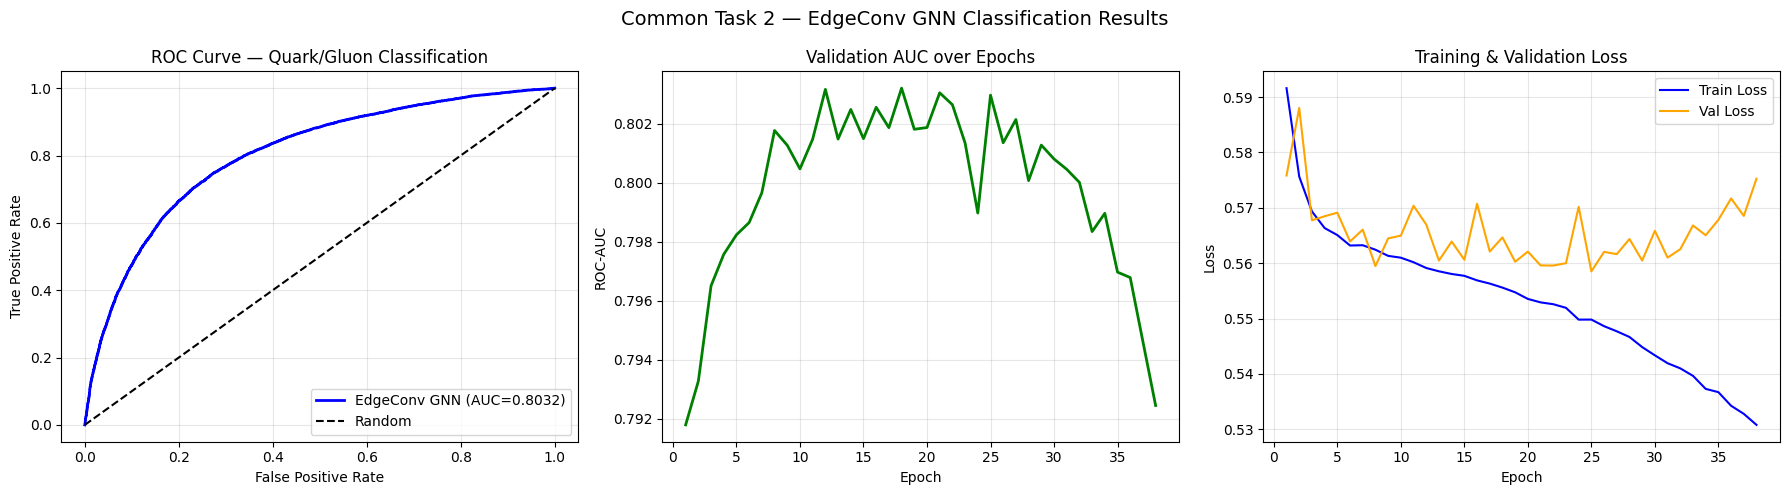

Final AUC: 0.8032


In [11]:
_, final_auc, preds, labels = eval_epoch(model, val_loader)
fpr, tpr, _ = roc_curve(labels, preds)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
axes[0].plot(fpr, tpr, label=f'EdgeConv GNN (AUC={final_auc:.4f})', color='blue', lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Quark/Gluon Classification')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC vs Epoch
axes[1].plot(range(1, len(val_aucs)+1), val_aucs, color='green', lw=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Validation AUC over Epochs')
axes[1].grid(True, alpha=0.3)

# Train/Val Loss
axes[2].plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', color='blue')
axes[2].plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', color='orange')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Training & Validation Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Common Task 2 — EdgeConv GNN Classification Results', fontsize=14)
plt.tight_layout()
os.makedirs('/content/Genie-Task/common_task2_gnn', exist_ok=True)
plt.savefig('/content/Genie-Task/common_task2_gnn/Task2_result.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final AUC: {final_auc:.4f}")

In [ ]:
# Save model
torch.save(model.state_dict(), '/content/Genie-Task/common_task2_gnn/models/jet_gcn.pth')
print(f"Model saved. Best AUC: {best_auc:.4f}")